In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Load the original/raw clinic appointment data
# Load the original/raw clinic appointment data
raw_path = "../raw/messy_clinic_appointments.csv"
df = pd.read_csv(raw_path)


In [4]:
import os
print(os.getcwd())


C:\Users\Bhoomi\Downloads\clinic-data-cleaning-github-ready\clinic-data-cleaning-github-ready\data\notebooks


In [6]:
df.head()

,patient_id,patient_name,age,gender,appointment_date,booking_date,doctor,department,billing_amount,follow_up_required
0,1080,Tammy Williams,76,female,2026/02/26,2024/12/03,Christopher Graham,Cardiology,£425.8,1
1,1074,Megan Strickland,69,F,05/23/2025,12-Jun-2024,Brandon Lewis,Orthopedics,€344.26,Y
2,1067,Amanda Schroeder,79,M,30-Nov-2025,"August 05, 24",Deanna Edwards,Neurology,€203.34,Y
3,1072,Anthony Mcpherson,47,F,"May 18, 25",09/09/2024,Karen Parsons,General,Rs85.76,No
4,1092,Benjamin Brown,45,NaN,2026/03/07,08/17/2024,Andrea Hernandez,General,$84.44,1


In [7]:
df.shape


(1000, 10)

In [8]:
df.columns

Index(['patient_id', 'patient_name', 'age', 'gender', 'appointment_date',
       'booking_date', 'doctor', 'department', 'billing_amount',
       'follow_up_required'],
      dtype='str')

In [9]:
df.info

<bound method DataFrame.info of      patient_id       patient_name  age  gender  appointment_date  \
0          1080     Tammy Williams   76  female        2026/02/26   
1          1074   Megan Strickland   69       F        05/23/2025   
2          1067   Amanda Schroeder   79       M       30-Nov-2025   
3          1072  Anthony Mcpherson   47       F        May 18, 25   
4          1092     Benjamin Brown   45     NaN        2026/03/07   
..          ...                ...  ...     ...               ...   
995        1082       Thomas Roman   64  Female  September 14, 25   
996        1008        Jack Cooper   67       F      April 09, 25   
997        1022  Christopher Brown   28       1   February 13, 26   
998        1088   Michael Sullivan   65       F        2025/07/04   
999        1003     Perry Crawford   79    Male       05-Nov-2025   

      booking_date              doctor   department billing_amount  \
0       2024/12/03  Christopher Graham   Cardiology         £425.8   

In [10]:
df.isnull().sum()

patient_id             0
patient_name           0
age                    0
gender                50
appointment_date       0
booking_date           0
doctor                 0
department             0
billing_amount        50
follow_up_required     0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.duplicated().sum()


np.int64(0)

In [13]:
for col in df.columns:
    print("\n---", col, "---")
    print(df[col].unique()[:20])



--- patient_id ---
[1080 1074 1067 1072 1092 1057 1018 1041 1011 1086 1022 1046 1025 1027
 1059 1033 1069 1097 1064 1089]

--- patient_name ---
<ArrowStringArray>
[   'Tammy Williams',  'Megan Strickland',  'Amanda Schroeder',
 'Anthony Mcpherson',    'Benjamin Brown',         'Joe Sharp',
  'Alexander Harris',  'Raymond Williams',     'Dustin Willis',
    'Tina Gallagher',   'Robert Guerrero',      'Karen Walker',
        'Chris Rice',      'Michael Mack',    'Andrea Hubbard',
       'Brian Jones',       'Kelly Olsen',    'Andrew Oconnor',
     'Dennis Hurley',        'Paul Brock']
Length: 20, dtype: str

--- age ---
[76 69 79 47 45 78 22 57 54 68 61 70 36 23 72 66 81 90 56 88]

--- gender ---
<ArrowStringArray>
['female', 'F', 'M', nan, '1', 'Female', 'male', 'Male', '0']
Length: 9, dtype: str

--- appointment_date ---
<ArrowStringArray>
[      '2026/02/26',       '05/23/2025',      '30-Nov-2025',
       'May 18, 25',       '2026/03/07', 'September 26, 25',
      '30-Oct-2025',     

In [14]:
df["gender"].value_counts(dropna=False)


gender
0         129
1         128
Male      123
Female    120
F         116
female    112
male      112
M         110
NaN        50
Name: count, dtype: int64

In [15]:
df["gender"] = df["gender"].replace({
    "Male": "Male",
    "male": "Male",
    "M": "Male",
    "1": "Male",
    "Female": "Female",
    "female": "Female",
    "F": "Female",
    "0": "Female"
})


In [16]:
df["gender"].value_counts(dropna=False)


gender
Female    477
Male      473
NaN        50
Name: count, dtype: int64

In [17]:
df["follow_up_required"].value_counts(dropna=False)


follow_up_required
0      185
Y      182
Yes    181
N      154
1      151
No     147
Name: count, dtype: int64

In [18]:
df["follow_up_required"] = df["follow_up_required"].replace({
    "Y": "Yes",
    "1": "Yes",
    "N": "No",
    "0": "No"
})


In [19]:
df["follow_up_required"].value_counts(dropna=False)


follow_up_required
Yes    514
No     486
Name: count, dtype: int64

In [20]:
df["appointment_date"] = pd.to_datetime(
    df["appointment_date"],
    errors="coerce"
)


In [21]:
df["appointment_date"].isnull().sum()


np.int64(739)

In [23]:
df["appointment_date"].head(20)


0    2026-02-26
1           NaT
2           NaT
3           NaT
4    2026-03-07
5           NaT
6           NaT
7    2025-04-23
8           NaT
9           NaT
10   2025-04-24
11   2026-03-07
12   2025-07-31
13          NaT
14   2026-03-12
15          NaT
16          NaT
17          NaT
18          NaT
19   2025-11-05
Name: appointment_date, dtype: datetime64[us]

In [26]:
# Re-read the raw appointment_date column so the mixed date formats are cleaned from the original data.
# Re-read the raw appointment_date column so the mixed date formats are cleaned from the original data.
df = pd.read_csv("../raw/messy_clinic_appointments.csv")

df["appointment_date"] = pd.to_datetime(
    df["appointment_date"],
    format="mixed",
    errors="coerce"
)

df["appointment_date"].isnull().sum()



np.int64(0)

In [27]:
df["appointment_date"].head()


0   2026-02-26
1   2025-05-23
2   2025-11-30
3   2025-05-18
4   2026-03-07
Name: appointment_date, dtype: datetime64[us]

In [28]:
df["appointment_date"].dtype


dtype('<M8[us]')

In [29]:
df["appointment_date"].min(), df["appointment_date"].max()


(Timestamp('2025-03-26 00:00:00'), Timestamp('2026-03-26 00:00:00'))

In [30]:
df.isnull().sum()


patient_id             0
patient_name           0
age                    0
gender                50
appointment_date       0
booking_date           0
doctor                 0
department             0
billing_amount        50
follow_up_required     0
dtype: int64

In [32]:
# Clean booking_date from the original/raw data.
# Clean booking_date from the original/raw data.
df["booking_date"] = pd.to_datetime(
    df["booking_date"],
    format="mixed",
    errors="coerce"
)

df["booking_date"].isnull().sum()



np.int64(0)

In [33]:
df["booking_date"].head()


0   2024-12-03
1   2024-06-12
2   2024-08-05
3   2024-09-09
4   2024-08-17
Name: booking_date, dtype: datetime64[us]

In [34]:
df["booking_date"].min(), df["booking_date"].max()


(Timestamp('2024-03-26 00:00:00'), Timestamp('2026-03-07 00:00:00'))

In [35]:
df["billing_amount"].head(20)


0       £425.8
1      €344.26
2      €203.34
3      Rs85.76
4       $84.44
5          NaN
6        €99.0
7     Rs374.63
8      $452.37
9      €494.97
10      £91.91
11      $82.88
12    Rs277.14
13     €411.01
14      £67.51
15     €163.99
16     £252.38
17     $153.07
18     Rs329.3
19     €135.45
Name: billing_amount, dtype: str

In [36]:
df["billing_amount"].isnull().sum()


np.int64(50)

In [37]:
df["currency"] = df["billing_amount"].str.extract(r"(Rs|[$€£])")


In [38]:
df["currency"].value_counts(dropna=False)


currency
Rs     252
$      241
€      237
£      220
NaN     50
Name: count, dtype: int64

In [39]:
df["billing_amount"] = (
    df["billing_amount"]
    .str.replace(r"Rs|[$€£]", "", regex=True)
    .str.strip()
)

df["billing_amount"] = pd.to_numeric(
    df["billing_amount"],
    errors="coerce"
)


In [40]:
df[["billing_amount", "currency"]].head(10)


,billing_amount,currency
0,425.80,£
1,344.26,€
2,203.34,€
3,85.76,Rs
4,84.44,$
5,NaN,NaN
6,99.00,€
7,374.63,Rs
8,452.37,$
9,494.97,€


In [41]:
df["billing_amount"].dtype


dtype('float64')

In [42]:
df.groupby("currency")["billing_amount"].median()


currency
$     261.870
Rs    282.370
£     261.585
€     270.470
Name: billing_amount, dtype: float64

In [43]:
df["billing_amount"].median()


np.float64(269.84)

In [44]:
df["billing_amount"] = df["billing_amount"].fillna(269.84)


In [45]:
df["billing_amount"].isnull().sum()


np.int64(0)

In [46]:
df["gender"].value_counts()


gender
0         129
1         128
Male      123
Female    120
F         116
female    112
male      112
M         110
Name: count, dtype: int64

In [47]:
df["gender"].mode()[0]


'0'

In [48]:
df["gender"] = df["gender"].fillna("Female")


In [49]:
df["gender"].isnull().sum()


np.int64(0)

In [50]:
df.isnull().sum()


patient_id             0
patient_name           0
age                    0
gender                 0
appointment_date       0
booking_date           0
doctor                 0
department             0
billing_amount         0
follow_up_required     0
currency              50
dtype: int64

In [51]:
df["currency"] = df["currency"].fillna("Unknown")


In [52]:
df.isnull().sum()


patient_id            0
patient_name          0
age                   0
gender                0
appointment_date      0
booking_date          0
doctor                0
department            0
billing_amount        0
follow_up_required    0
currency              0
dtype: int64

In [53]:
df.duplicated().sum()


np.int64(0)

In [54]:
df.dtypes


patient_id                     int64
patient_name                     str
age                            int64
gender                           str
appointment_date      datetime64[us]
booking_date          datetime64[us]
doctor                           str
department                       str
billing_amount               float64
follow_up_required               str
currency                         str
dtype: object

In [55]:
df.head()

,patient_id,patient_name,age,gender,appointment_date,booking_date,doctor,department,billing_amount,follow_up_required,currency
0,1080,Tammy Williams,76,female,2026-02-26,2024-12-03,Christopher Graham,Cardiology,425.80,1,£
1,1074,Megan Strickland,69,F,2025-05-23,2024-06-12,Brandon Lewis,Orthopedics,344.26,Y,€
2,1067,Amanda Schroeder,79,M,2025-11-30,2024-08-05,Deanna Edwards,Neurology,203.34,Y,€
3,1072,Anthony Mcpherson,47,F,2025-05-18,2024-09-09,Karen Parsons,General,85.76,No,Rs
4,1092,Benjamin Brown,45,Female,2026-03-07,2024-08-17,Andrea Hernandez,General,84.44,1,$


In [56]:
df.describe()


,patient_id,age,appointment_date,booking_date,billing_amount
count,1000.000000,1000.000000,1000,1000,1000.000000
mean,1050.521000,53.750000,2025-10-01 12:48:57.600000,2024-12-30 23:18:14.400000,275.803030
min,1000.000000,18.000000,2025-03-26 00:00:00,2024-03-26 00:00:00,51.380000
25%,1025.000000,34.000000,2025-07-05 00:00:00,2024-08-14 00:00:00,166.495000
50%,1051.000000,55.000000,2025-10-08 12:00:00,2024-12-22 00:00:00,269.840000
75%,1075.000000,71.000000,2025-12-28 00:00:00,2025-05-09 06:00:00,383.872500
max,1100.000000,90.000000,2026-03-26 00:00:00,2026-03-07 00:00:00,499.750000
std,28.888581,21.137604,NaN,NaN,126.833397


In [57]:
df["department"].value_counts()


department
Neurology      273
Orthopedics    262
Cardiology     234
General        231
Name: count, dtype: int64

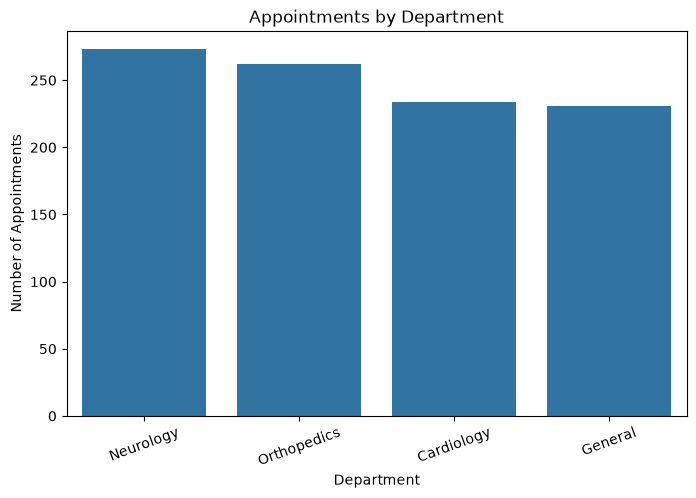

In [58]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="department",
    order=df["department"].value_counts().index
)

plt.title("Appointments by Department")
plt.xlabel("Department")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=20)
plt.show()


In [59]:
df["gender"].value_counts()


gender
Female    170
0         129
1         128
Male      123
F         116
female    112
male      112
M         110
Name: count, dtype: int64

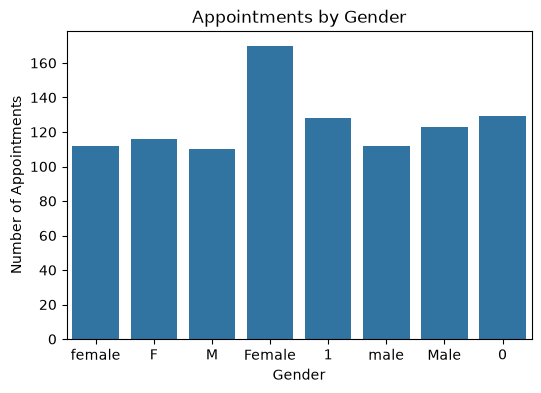

In [60]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="gender")

plt.title("Appointments by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Appointments")
plt.show()


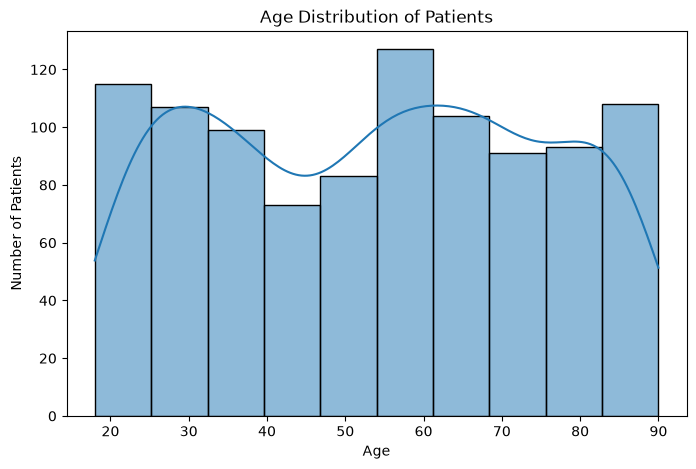

In [61]:
plt.figure(figsize=(8, 5))

sns.histplot(df["age"], bins=10, kde=True)

plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()


In [62]:
df["age"].mean(), df["age"].median()


(np.float64(53.75), np.float64(55.0))

In [63]:
df["follow_up_required"].value_counts()


follow_up_required
0      185
Y      182
Yes    181
N      154
1      151
No     147
Name: count, dtype: int64

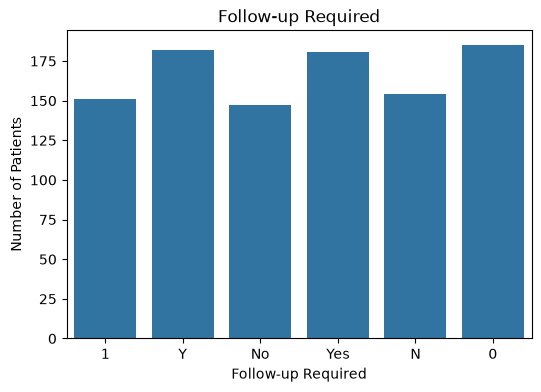

In [64]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="follow_up_required")

plt.title("Follow-up Required")
plt.xlabel("Follow-up Required")
plt.ylabel("Number of Patients")
plt.show()


In [65]:
df["billing_amount"].describe()


count    1000.000000
mean      275.803030
std       126.833397
min        51.380000
25%       166.495000
50%       269.840000
75%       383.872500
max       499.750000
Name: billing_amount, dtype: float64

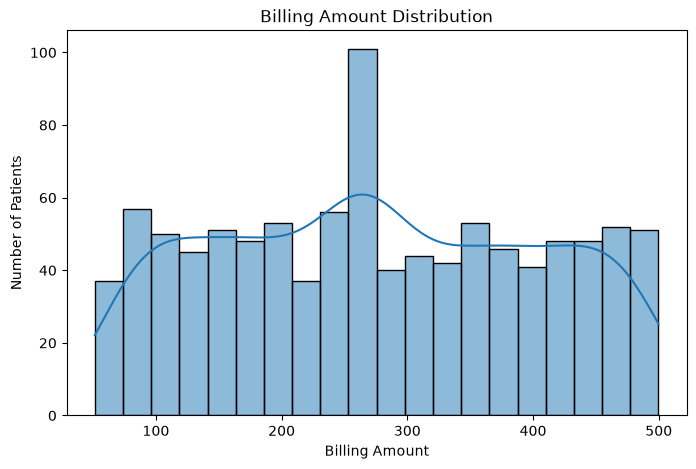

In [66]:
plt.figure(figsize=(8, 5))

sns.histplot(df["billing_amount"], bins=20, kde=True)

plt.title("Billing Amount Distribution")
plt.xlabel("Billing Amount")
plt.ylabel("Number of Patients")
plt.show()


In [67]:
df.groupby("department")["billing_amount"].mean().sort_values(ascending=False)


department
General        290.190909
Orthopedics    278.589084
Neurology      274.890293
Cardiology     259.545043
Name: billing_amount, dtype: float64

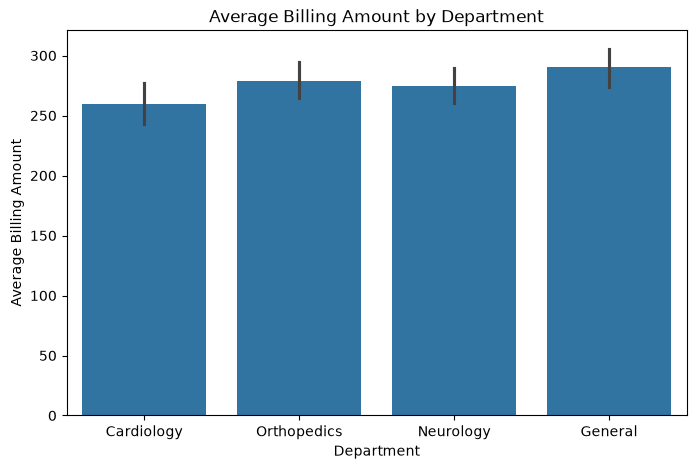

In [68]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="department",
    y="billing_amount",
    estimator="mean"
)

plt.title("Average Billing Amount by Department")
plt.xlabel("Department")
plt.ylabel("Average Billing Amount")
plt.show()


In [69]:
df["appointment_month"] = df["appointment_date"].dt.to_period("M")


In [70]:
monthly_appointments = df["appointment_month"].value_counts().sort_index()
monthly_appointments


appointment_month
2025-03     15
2025-04     63
2025-05     88
2025-06     69
2025-07     83
2025-08     79
2025-09     79
2025-10    104
2025-11     91
2025-12     89
2026-01     84
2026-02     91
2026-03     65
Freq: M, Name: count, dtype: int64

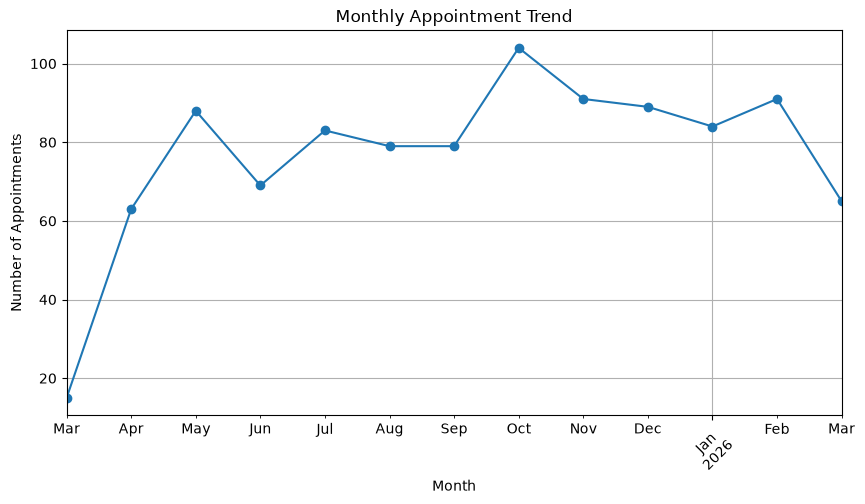

In [71]:
plt.figure(figsize=(10, 5))

monthly_appointments.plot(marker="o")

plt.title("Monthly Appointment Trend")
plt.xlabel("Month")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()



In [72]:
df["age"].corr(df["billing_amount"])


np.float64(0.0048363056388555726)

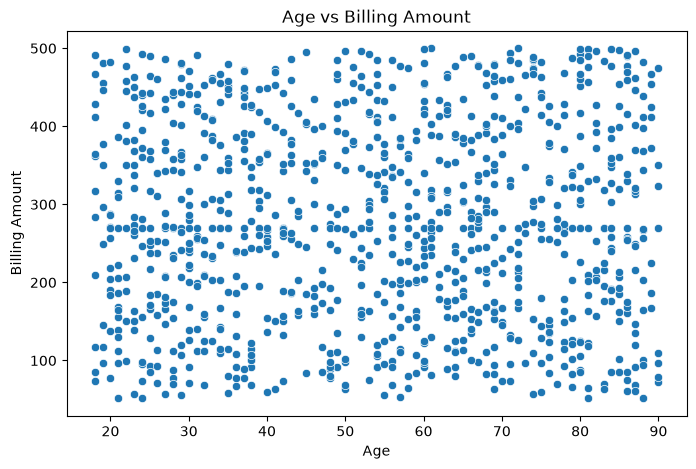

In [73]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="age",
    y="billing_amount"
)

plt.title("Age vs Billing Amount")
plt.xlabel("Age")
plt.ylabel("Billing Amount")
plt.show()


In [74]:
pd.crosstab(
    df["department"],
    df["follow_up_required"]
)


follow_up_required,0,1,N,No,Y,Yes
department,,,,,,
Cardiology,38,41,44,32,46,33
General,43,37,33,30,45,43
Neurology,57,35,34,42,44,61
Orthopedics,47,38,43,43,47,44


In [75]:
followup_pct = pd.crosstab(
    df["department"],
    df["follow_up_required"],
    normalize="index"
) * 100

followup_pct.round(2)


follow_up_required,0,1,N,No,Y,Yes
department,,,,,,
Cardiology,16.24,17.52,18.80,13.68,19.66,14.10
General,18.61,16.02,14.29,12.99,19.48,18.61
Neurology,20.88,12.82,12.45,15.38,16.12,22.34
Orthopedics,17.94,14.50,16.41,16.41,17.94,16.79


In [76]:
df["booking_to_appointment_days"] = (
    df["appointment_date"] - df["booking_date"]
).dt.days


In [77]:
df["booking_to_appointment_days"].describe()


count    1000.000000
mean      274.563000
std       170.492327
min         2.000000
25%       130.750000
50%       258.500000
75%       395.250000
max       728.000000
Name: booking_to_appointment_days, dtype: float64

In [78]:
df["doctor"].value_counts().head(10)


doctor
Jennifer Adams       2
Nancy Hernandez      2
Wesley Johnson       2
Michael Wright       2
Christopher Smith    2
James Aguilar        2
Kristen Lopez        2
Jennifer Carroll     2
Nancy Wilson         2
Benjamin Brown       2
Name: count, dtype: int64

In [79]:
df["doctor"].nunique()


990

In [80]:
df["doctor"].value_counts().value_counts().sort_index()


count
1    980
2     10
Name: count, dtype: int64

In [81]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   patient_id                   1000 non-null   int64         
 1   patient_name                 1000 non-null   str           
 2   age                          1000 non-null   int64         
 3   gender                       1000 non-null   str           
 4   appointment_date             1000 non-null   datetime64[us]
 5   booking_date                 1000 non-null   datetime64[us]
 6   doctor                       1000 non-null   str           
 7   department                   1000 non-null   str           
 8   billing_amount               1000 non-null   float64       
 9   follow_up_required           1000 non-null   str           
 10  currency                     1000 non-null   str           
 11  appointment_month            1000 non-null   period[M] 

In [82]:
df.head()


,patient_id,patient_name,age,gender,appointment_date,booking_date,doctor,department,billing_amount,follow_up_required,currency,appointment_month,booking_to_appointment_days
0,1080,Tammy Williams,76,female,2026-02-26,2024-12-03,Christopher Graham,Cardiology,425.80,1,£,2026-02,450
1,1074,Megan Strickland,69,F,2025-05-23,2024-06-12,Brandon Lewis,Orthopedics,344.26,Y,€,2025-05,345
2,1067,Amanda Schroeder,79,M,2025-11-30,2024-08-05,Deanna Edwards,Neurology,203.34,Y,€,2025-11,482
3,1072,Anthony Mcpherson,47,F,2025-05-18,2024-09-09,Karen Parsons,General,85.76,No,Rs,2025-05,251
4,1092,Benjamin Brown,45,Female,2026-03-07,2024-08-17,Andrea Hernandez,General,84.44,1,$,2026-03,567


In [83]:
df.isnull().sum()


patient_id                     0
patient_name                   0
age                            0
gender                         0
appointment_date               0
booking_date                   0
doctor                         0
department                     0
billing_amount                 0
follow_up_required             0
currency                       0
appointment_month              0
booking_to_appointment_days    0
dtype: int64

In [84]:
print("Total Patients:", len(df))
print("Average Age:", round(df["age"].mean(), 2))
print("Average Billing:", round(df["billing_amount"].mean(), 2))
print("Follow-up Required:", (df["follow_up_required"] == "Yes").sum())
print("Total Departments:", df["department"].nunique())
print("Total Doctors:", df["doctor"].nunique())


Total Patients: 1000
Average Age: 53.75
Average Billing: 275.8
Follow-up Required: 181
Total Departments: 4
Total Doctors: 990


In [85]:
print("Total Appointments:", len(df))
print("Unique Patients:", df["patient_id"].nunique())
print("Average Age:", round(df["age"].mean(), 2))
print("Average Billing:", round(df["billing_amount"].mean(), 2))
print("Follow-up Required:", (df["follow_up_required"] == "Yes").sum())
print("Departments:", df["department"].nunique())
print("Unique Doctors:", df["doctor"].nunique())


Total Appointments: 1000
Unique Patients: 101
Average Age: 53.75
Average Billing: 275.8
Follow-up Required: 181
Departments: 4
Unique Doctors: 990


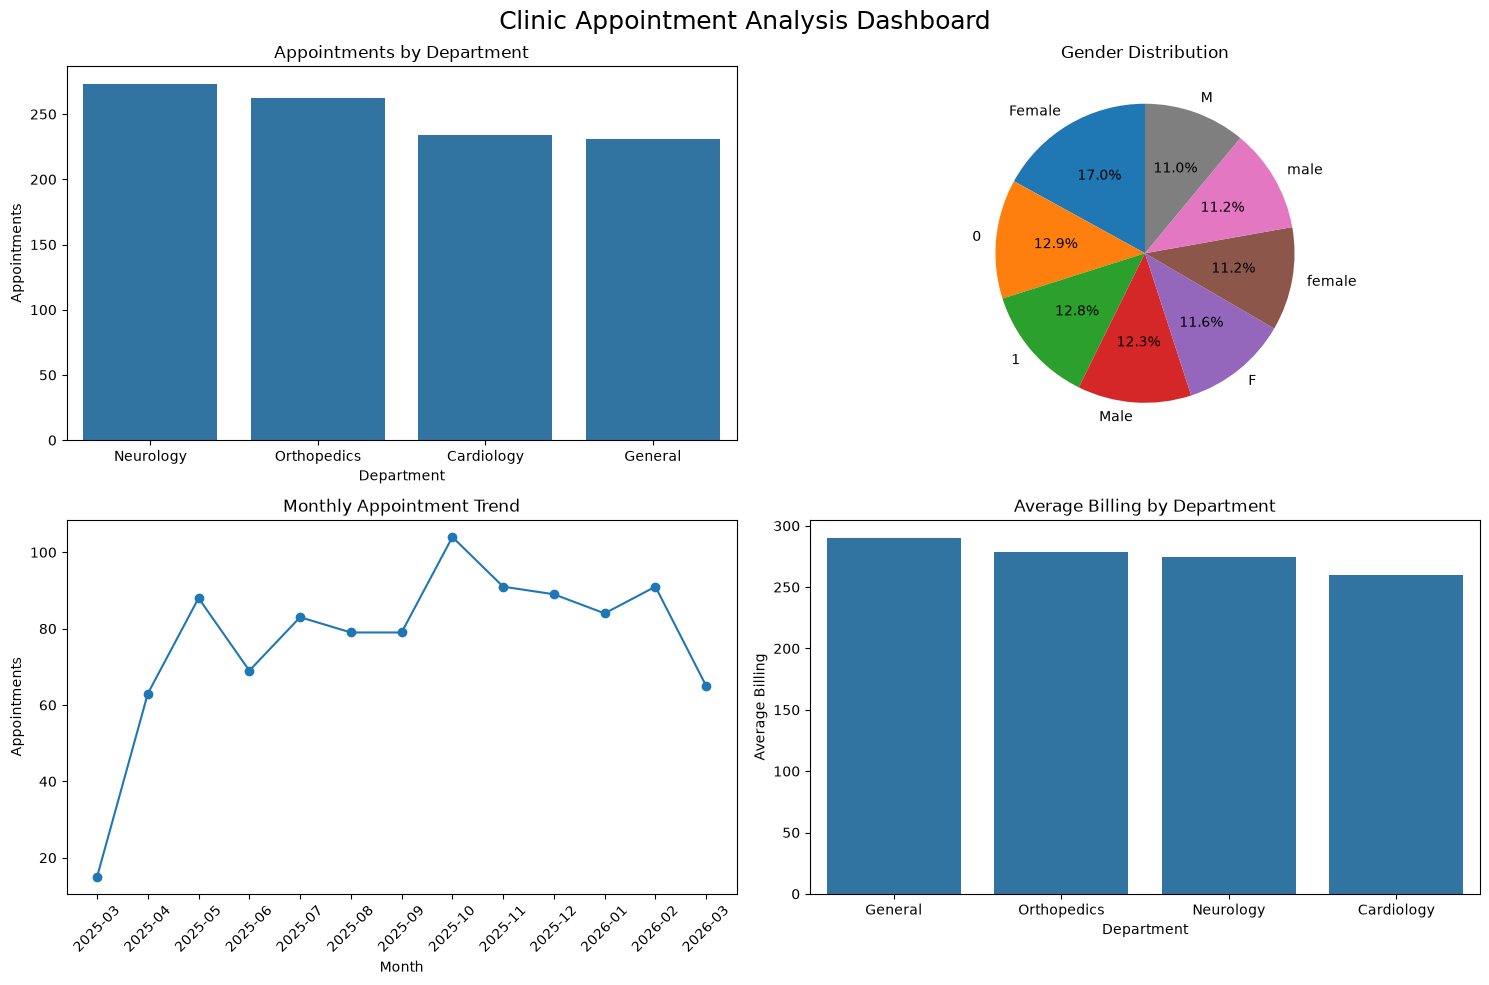

In [86]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Department-wise appointments
department_counts = df["department"].value_counts()

sns.barplot(
    x=department_counts.index,
    y=department_counts.values,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Appointments by Department")
axes[0, 0].set_xlabel("Department")
axes[0, 0].set_ylabel("Appointments")

# 2. Gender distribution
gender_counts = df["gender"].value_counts()

axes[0, 1].pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
axes[0, 1].set_title("Gender Distribution")

# 3. Monthly appointment trend
monthly_counts = df["appointment_month"].value_counts().sort_index()

axes[1, 0].plot(
    monthly_counts.index.astype(str),
    monthly_counts.values,
    marker="o"
)
axes[1, 0].set_title("Monthly Appointment Trend")
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_ylabel("Appointments")
axes[1, 0].tick_params(axis="x", rotation=45)

# 4. Average billing by department
billing_by_dept = (
    df.groupby("department")["billing_amount"]
    .mean()
    .sort_values(ascending=False)
)

sns.barplot(
    x=billing_by_dept.index,
    y=billing_by_dept.values,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Average Billing by Department")
axes[1, 1].set_xlabel("Department")
axes[1, 1].set_ylabel("Average Billing")

plt.suptitle("Clinic Appointment Analysis Dashboard", fontsize=18)
plt.tight_layout()
plt.show()


In [87]:
print("=== KEY INSIGHTS ===")

print("Highest Appointment Department:")
print(df["department"].value_counts().idxmax())

print("\nHighest Average Billing Department:")
print(
    df.groupby("department")["billing_amount"]
    .mean()
    .idxmax()
)

print("\nHighest Appointment Month:")
print(
    df["appointment_month"].value_counts().idxmax()
)

print("\nFollow-up Rate:")
print(
    round((df["follow_up_required"] == "Yes").mean() * 100, 2),
    "%"
)

print("\nAverage Booking-to-Appointment Gap:")
print(
    round(df["booking_to_appointment_days"].mean(), 2),
    "days"
)

print("\nAge-Billing Correlation:")
print(
    round(df["age"].corr(df["billing_amount"]), 4)
)


=== KEY INSIGHTS ===
Highest Appointment Department:
Neurology

Highest Average Billing Department:
General

Highest Appointment Month:
2025-10

Follow-up Rate:
18.1 %

Average Booking-to-Appointment Gap:
274.56 days

Age-Billing Correlation:
0.0048


In [89]:
# Save the final cleaned dataset inside the repository.
import os

output_path = "../data/processed/cleaned_clinic_appointments.csv"

os.makedirs("../data/processed", exist_ok=True)

df.to_csv(output_path, index=False)

print("File saved successfully!")
print(output_path)



File saved successfully!
../data/processed/cleaned_clinic_appointments.csv
